# HTDemucs - Spatially-Aware Fine-Tune on binauralMUSDB18

Fine-tunes the **full pre-trained HTDemucs backbone** on the binauralMUSDB18-HQ
dataset so that **HTDemucs itself learns to preserve the binaural spatial cues** —
*without* adding any `SpatialCueModule` head (that is the SA-HTDemucs approach).

The objective augments the original HTDemucs training loss with a
**sub-band ILD MSE** spatial term:

$$\mathcal{L} = \lambda_{\text{td}} \underbrace{\tfrac{1}{S}\sum_s \|\hat{s} - s\|_1}_{\text{time-domain L1}}
 + \lambda_{\text{ild}} \underbrace{\tfrac{1}{S}\sum_s \big\|\widehat{\text{ILD}}^{(s)} - \text{ILD}^{(s)}_{\text{gt}}\big\|_2^2}_{\text{sub-band ILD MSE}}
  + \lambda_{\text{itd}} \underbrace{\tfrac{1}{S}\sum_s \big\|\widehat{\text{ITD}}^{(s)} - \text{ITD}^{(s)}_{\text{gt}}\big\|_2^2}_{\text{sub-band ITD MSE}}$$

The first term is  the original HTDemucs objective, namely a plain time-domain L1 on the waveforms
(Rouard et al., 2022). It keeps separation quality at the original HTDemucs level. The second term is
the per-sub-band ILD MSE that drives the backbone to preserve the spatial cues of each source at the
higher frequencies. The third term is the per-sub-band ITD MSE that drives the backbone to preserve
the spatial cues of each source at the lower frequencies.

**Memory strategy** (HTDemucs ~80M params):
- `torch.cuda.amp` (FP16) - halves activation memory
- `ACCUM_STEPS` gradient accumulation - effective batch = `BATCH_SIZE × ACCUM_STEPS`

> **Prerequisite:** `pip install demucs`

In [1]:
import sys
from pathlib import Path

# Robustly locate the project root (the folder containing the `sahtdemucs` package)
_cwd = Path().resolve()
_project_root = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'sahtdemucs' / '__init__.py').exists()),
    _cwd.parent,
)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import math
from datetime import datetime
from pathlib import Path
import random
import time
from typing import Optional

import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader

import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.dataset import MusdbSpatialDataset, load_audio
from sahtdemucs.spatial import mel_bin_assignment
from sahtdemucs.losses import HTDemucsSpatialLoss
from sahtdemucs.metrics import si_sdr, ild_bands_mae, itd_bands_mae

## Configuration

In [2]:
# ── Remote or local ───────────────────────────────────────────────────────────
remote   = True
training = True

# ── Paths ─────────────────────────────────────────────────────────────────────
if training:
    _run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    _run_ts = "decoder_tail_20260716_135536"   # <-- set to the run you want to resume/evaluate

if remote:
    DATASET_ROOT    = Path("/nas/home/macerbi/Dataset/binauralMUSMOISESDB")
    CKPT_DIR        = Path("/nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune")
    ESTIMATES_DIR   = CKPT_DIR / f"estimates_{_run_ts}"
else:
    DATASET_ROOT    = Path(r"D:\Polimi\PhD\Dataset\binauralMUSMOISESDB")
    CKPT_DIR        = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\htdemucs_spatial_finetune")
    ESTIMATES_DIR   = Path(f"D:\Polimi\PhD\Dataset\HTDemucsSpatial\estimates_{_run_ts}")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / f"htdmcs_sp_{_run_ts}.pt"

# ── Training hyper-parameters ─────────────────────────────────────────────────
FREEZE_STRATEGY = "zdecoder_tail"   # fine-tuning strategy
N_EPOCHS        = 300               # number of epochs
BATCH_SIZE      = 4                 # batch size
ACCUM_STEPS     = 4                 # effective batch = 4
LR              = 1e-4              # larning rate
VALID_SPLIT     = 0.2               # validation set split
CROPS_PER_TRACK = 4                 # random segments drawn per training track at each epoch
MIN_RMS         = 1e-4              # skip near-silent random crops (0 = disabled)
N_WORKERS       = 0

# ── Loss weights ──────────────────────────────────────────────────────────────
LAMBDA_TD       = 1.0               # time-domain L1 (separation) - the original HTDemucs loss
LAMBDA_ILD      = 1e-4              # sub-band ILD MSE (spatial) - level cue
LAMBDA_ITD      = 0.0               # sub-band ITD MSE (spatial) - time/phase cue

# Sub-band spatial-cue configuration (shared by the ILD and ITD terms so both
# have the same band layout). It mirrors the SA-HTDemucs setup.
ILD_N_FFT      = 4096
ILD_HOP        = 512
ILD_N_BANDS    = 64
ILD_BAND_SCALE = "mel"              # "linear" or "mel"

# ITD GCC-PHAT parameters
ITD_MAX_LAG    = 64                 # ± samples searched (±1.45 ms @ 44.1 kHz)
ITD_BETA       = 20.0               # soft-argmax temperature

# ── Mixed precision ───────────────────────────────────────────────────────────
USE_AMP         = True              # FP16 AMP for the forward/backward; the loss is computed in FP32

# ── Misc ──────────────────────────────────────────────────────────────────────
SOURCES = ["drums", "bass", "other", "vocals"]
COLORS  = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE  = _pick_free_gpu()

print(f"Dataset: {DATASET_ROOT}")
if training:
    print(f"Checkpoint will be saved to: {CKPT_PATH}")
else:
    print(f"Checkpoint loaded: {CKPT_PATH}")
print(f"Run    : {_run_ts}")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset: /nas/home/macerbi/Dataset/binauralMUSMOISESDB
Checkpoint will be saved to: /nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune/htdmcs_sp_20260722_101301.pt
Run    : 20260722_101301
Device : cuda:1
Device name: NVIDIA TITAN RTX
VRAM: 25.4 GB


## Load HTDemucs & choose the fine-tuning strategy

HTDemucs is a U-Net with a large cross-domain **transformer at the bottleneck
(~75% of the weights)** and 4-level frequency/time **encoder** and **decoder**
branches (skip-connected `encoder[i]` ↔ `decoder[3−i]`).  Note the indexing:
`decoder[0]` is the *first* decoder block (near the bottleneck), `decoder[3]` is
the *last* one, closest to the output.

The binaural cues we supervise are **output-side** phenomena). So the recommended
recipe is to **freeze the transformer**, that is the separation core *and* the bulk
of the memory, and train only the output-side decoder blocks.

Pick the recipe with `FREEZE_STRATEGY` in the next cell:

| strategy                    | trains                                        |
|-----------------------------|-----------------------------------------------|
| `zdecoder_tail` *(default)* | `decoder[3:]`                                 |
| `decoder_tail`              | `decoder[2:]`, `tdecoder[2:]`                 |
| `decoder_tail+tenc0`        | `decoder[2:]`, `tdecoder[2:]` + `tencoder[0]` |
| `symmetric`                 | skip-paired `encoder[:2]` + `decoder[2:]`     |
| `full_decoder`              | whole `decoder` + `tdecoder`                  |
| `decoder+transformer`       | encoders frozen only                          |
| `none`                      | everything                                    |

In [3]:
# ── Fine-tuning strategy: which layers to train vs freeze ─────────────────
# HTDemucs is a U-Net with a huge cross-domain transformer at the bottleneck
# (~75% of the weights) plus 4-level freq/time encoder & decoder branches.
# The binaural cues we supervise are OUTPUT-side phenomena:
#   * ILD (level)      -> last decoder blocks (decoder[3], tdecoder[3], + ISTFT)
#   * ITD (time/phase) -> low-level TIME branch (tencoder[0], tdecoder[3])
# Safest recipe: FREEZE the transformer (protects separation, saves the most
# memory) and train only the output-side decoder blocks.  See the table above.
#
#   "decoder_tail"        train decoder[2:] + tdecoder[2:]          (recommended, ILD)
#   "decoder_tail+tenc0"  + tencoder[0]                             (add when LAMBDA_ITD>0)
#   "symmetric"           skip-paired encoder[:2] + decoder[2:] (both branches)
#   "full_decoder"        whole decoder + tdecoder, transformer/encoders frozen
#   "decoder+transformer" original notebook recipe (freeze encoders only)
#   "none"                full fine-tune (nothing frozen)

bag   = get_model("htdemucs")
model = bag.models[0] if hasattr(bag, "models") else bag
model = model.to(DEVICE)

SAMPLE_RATE = model.samplerate                          # 44100 Hz
SEG_LEN     = int(float(model.segment) * SAMPLE_RATE)   # ~ 8 seconds

def apply_freeze_strategy(model, strategy):
    """Set requires_grad per `strategy`; return {group_name: [params]} for logging."""
    def flat(*mods):
        return [p for m in mods for p in m.parameters()]

    enc,  tenc = list(model.encoder), list(model.tencoder)
    dec,  tdec = list(model.decoder), list(model.tdecoder)

    # Strategies given as the TRAINABLE groups (everything else is frozen).
    unfreeze = {
        "zdecoder_tail":      {"decoder[3:]":  flat(*dec[3:])},
        "decoder_tail":       {"decoder[2:]":  flat(*dec[2:]),
                               "tdecoder[2:]": flat(*tdec[2:])},
        "decoder_tail+tenc0": {"decoder[2:]":  flat(*dec[2:]),
                               "tdecoder[2:]": flat(*tdec[2:]),
                               "tencoder[0]":  flat(tenc[0])},
        "symmetric":          {"encoder[:2]":  flat(*enc[:2]),
                               "decoder[2:]":  flat(*dec[2:]),
                               "tencoder[:2]": flat(*tenc[:2]),
                               "tdecoder[2:]": flat(*tdec[2:])},
        "full_decoder":       {"decoder":  flat(*dec),
                               "tdecoder": flat(*tdec)},
    }
    # Strategies given as the FROZEN groups (everything else stays trainable).
    freeze = {
        "decoder+transformer": {"encoder": flat(*enc), "tencoder": flat(*tenc)},
        "none":                {},
    }

    if strategy in unfreeze:
        for p in model.parameters():
            p.requires_grad_(False)
        groups = {k: v for k, v in unfreeze[strategy].items() if v}
        for params in groups.values():
            for p in params:
                p.requires_grad_(True)
        return groups
    if strategy in freeze:
        for p in model.parameters():
            p.requires_grad_(True)
        for params in freeze[strategy].values():
            for p in params:
                p.requires_grad_(False)
        trainable = [p for p in model.parameters() if p.requires_grad]
        return {"all" if not freeze[strategy] else "all except frozen": trainable}
    raise ValueError(
        f"Unknown FREEZE_STRATEGY {strategy!r}; choose one of "
        f"{list(unfreeze) + list(freeze)}"
    )

groups      = apply_freeze_strategy(model, FREEZE_STRATEGY)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
n_total     = n_trainable + n_frozen

print(f"Model            : {type(model).__name__}")
print(f"Sources          : {model.sources}")
print(f"Sample rate      : {SAMPLE_RATE} Hz")
print(f"HTDemucs segment : {float(model.segment):.2f} s  ({SEG_LEN} samples)")
print(f"Freeze strategy  : {FREEZE_STRATEGY}")
print(f"Trainable params : {n_trainable:,}  ({100 * n_trainable / n_total:.1f}%)")
print(f"Frozen params    : {n_frozen:,}")
for name, params in groups.items():
    print(f"    trainable[{name}] = {sum(p.numel() for p in params):,}")

Model            : HTDemucs
Sources          : ['drums', 'bass', 'other', 'vocals']
Sample rate      : 44100 Hz
HTDemucs segment : 7.80 s  (343980 samples)
Freeze strategy  : zdecoder_tail
Trainable params : 51,316  (0.1%)
Frozen params    : 41,933,140
    trainable[decoder[3:]] = 51,316


## Loss Function - Time-domain L1 (separation) + Sub-band ILD & ITD MSE (spatial)

The objective combines a separation term with two spatial-cue terms, each
averaged over the $S$ sources:

1. **Time-domain L1** - the *exact* original HTDemucs separation objective.
   Rouard et al. (2022) train HTDemucs with *"the L1 loss on the waveforms"*
   only; there is **no** multi-scale spectrogram / frequency-domain term.
2. **Sub-band ILD MSE** - MSE on the per-sub-band Interaural **Level**
   Difference (the *level* spatial cue).
3. **Sub-band ITD MSE** - MSE on the per-sub-band Interaural **Time**
   Difference, estimated with a differentiable band-limited GCC-PHAT (the
   *time/phase* spatial cue). Both cues share the same band layout, so both
   have shape $(B, K, T_f)$.

$$\mathcal{L} = \lambda_{\text{td}}\,\|\hat{s}-s\|_1
 + \lambda_{\text{ild}}\,\big\|\widehat{\text{ILD}} - \text{ILD}_{gt}\big\|_2^2
 + \lambda_{\text{itd}}\,\big\|\widehat{\text{ITD}} - \text{ITD}_{gt}\big\|_2^2$$

The ILD of a stereo source per frequency sub-band $k$ and STFT frame $t$ is
$\widehat{\text{ILD}}_k(t) = 20\log_{10}(\text{RMS}_L[B_k]/\text{RMS}_R[B_k])$
in dB, with $B_k$ the STFT bins of band $k$ (Mel-spaced when
`ILD_BAND_SCALE="mel"`); the ITD is the GCC-PHAT lag (in **samples**) of the
same band. There is no SI-SDR degradation penalty here (it needs a frozen *raw*
HTDemucs baseline, which does not exist once the whole backbone is fine-tuned).

> **Scale note:** the ITD is in samples² while the ILD is in dB², so
> `LAMBDA_ITD` is set ≪ `LAMBDA_ILD`. Set `LAMBDA_ITD = 0.0` to train on ILD only.

> The loss is computed in **FP32** even under AMP (the inputs are cast to float),
> since the `log` / division / soft-argmax are numerically fragile in FP16.

In [4]:
spatial_loss = HTDemucsSpatialLoss(
    lambda_td=LAMBDA_TD,
    lambda_ild=LAMBDA_ILD,
    lambda_itd=LAMBDA_ITD,
    n_fft=ILD_N_FFT,
    hop_length=ILD_HOP,
    n_bands=ILD_N_BANDS,
    band_scale=ILD_BAND_SCALE,
    sample_rate=SAMPLE_RATE,
    itd_max_lag=ITD_MAX_LAG,
    itd_beta=ITD_BETA,
)
print("Loss: HTDemucsSpatialLoss")
print(f"  lambda_td   = {LAMBDA_TD}   (time-domain L1 — original HTDemucs loss)")
print(f"  lambda_ild  = {LAMBDA_ILD}   (sub-band ILD MSE @ n_fft={ILD_N_FFT}, "
      f"n_bands={ILD_N_BANDS}, {ILD_BAND_SCALE})")
print(f"  lambda_itd  = {LAMBDA_ITD}   (sub-band ITD MSE, GCC-PHAT, "
      f"max_lag={ITD_MAX_LAG})")

Loss: HTDemucsSpatialLoss
  lambda_td   = 1.0   (time-domain L1 — original HTDemucs loss)
  lambda_ild  = 0.0001   (sub-band ILD MSE @ n_fft=4096, n_bands=64, mel)
  lambda_itd  = 0.0   (sub-band ITD MSE, GCC-PHAT, max_lag=64)


## Dataset

In [5]:
full_ds = MusdbSpatialDataset(
    DATASET_ROOT,
    split               = "train",
    sources             = SOURCES,
    segment_len         = SEG_LEN,
    sample_rate         = SAMPLE_RATE,
    augment             = True,
    crops_per_track     = CROPS_PER_TRACK,
    min_rms             = MIN_RMS,
)

# ── Track-level split (mirrors SA-HTDemucs) ──────────────────────────────────
# Split on whole tracks, not on crops, so that random segments of the same song
# never leak across the train/valid boundary.  `full_ds.subset(...)` clones the
# dataset config and swaps in the track subset without re-scanning the disk.
n_valid = max(1, int(len(full_ds.tracks) * VALID_SPLIT))
n_train = len(full_ds.tracks) - n_valid

train_ds = full_ds.subset(full_ds.tracks[:n_train], crops_per_track=CROPS_PER_TRACK)
valid_ds = full_ds.subset(full_ds.tracks[n_train:], crops_per_track=1, augment=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"),
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"),
)

print(f"Train tracks : {n_train} x {CROPS_PER_TRACK} crops =  {len(train_ds)} items ({len(train_loader)} batches @batch={BATCH_SIZE}, accum={ACCUM_STEPS})")
print(f"Valid tracks : {n_valid} ({len(valid_loader)} batches)")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Train tracks : 244 x 4 crops =  976 items (244 batches @batch=4, accum=4)
Valid tracks : 60 (15 batches)
Effective batch size: 16


## Export crops for listening (optional)

Dump every train/validation crop (mixture + stems) to disk so you can listen to
what the model actually receives. This is handy to sanity-check the augmentation and the
non-silent-crop selection. Set `DUMP_CROPS = True` and run the cell.

In [7]:
# Set DUMP_CROPS=True to write, for every crop the model would see, the (2, T)
# mixture + (S, 2, T) stems as WAVs under CROPS_DUMP_DIR/<split>/<track>__crop<k>/.
# Training crops are random per epoch (this dumps one realization); the validation
# dump reuses run_valid()'s seed, so it is exactly the set you validate on.
DUMP_CROPS     = True
CROPS_DUMP_DIR = CKPT_DIR / f"crops_{_run_ts}"

def dump_crops(ds, out_dir, tag, seed=None):
    """Write every crop of `ds` (mixture + stems) as WAVs under `out_dir`."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
    n_tracks = len(ds.tracks)
    for i in range(len(ds)):
        mix, stems = ds[i]                       # (2, T), (S, 2, T)
        # If augmentation pushed the peak above 1.0, scale mix and every stem by
        # the SAME factor so 16-bit WAV won't clip; a common scalar preserves the
        # mix = sum-of-stems identity and all interaural level ratios (the ILD).
        peak = mix.abs().max().clamp(min=1.0)
        mix, stems = mix / peak, stems / peak
        d = out_dir / f"{ds.tracks[i % n_tracks].name}__crop{i // n_tracks}"
        d.mkdir(parents=True, exist_ok=True)
        torchaudio.save(str(d / "mixture.wav"), mix, SAMPLE_RATE)
        for s, src in enumerate(SOURCES):
            torchaudio.save(str(d / f"{src}.wav"), stems[s], SAMPLE_RATE)
    print(f"  {tag:5s}: {len(ds)} crops -> {out_dir}")

if DUMP_CROPS:
    print(f"Dumping crops under {CROPS_DUMP_DIR} ...")
    dump_crops(train_ds, CROPS_DUMP_DIR / "train", "train")
    dump_crops(valid_ds, CROPS_DUMP_DIR / "valid", "valid", seed=1234)
    print("Done.")
else:
    print("DUMP_CROPS=False - set it to True to write all train/valid crops to disk.")

Dumping crops under /nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune/crops_20260716_135536 ...


KeyboardInterrupt: 

## Training Loop

Key implementation details:

- **AMP (`autocast`)** — forward pass in FP16; the loss itself is evaluated in
  FP32 (inputs are cast inside `HTDemucsSpatialLoss`) so the ILD `log`/division
  stay numerically stable. The scaler handles gradient scaling.
- **Gradient accumulation** — `optimizer.step()` every `ACCUM_STEPS` batches,
  for an effective batch of `BATCH_SIZE × ACCUM_STEPS` without extra VRAM.
- **Gradient clipping** (`max_norm=5`) — stabilises fine-tuning of the backbone.

The three loss components (td / ild / itd) are logged separately so you can see
whether the spatial terms are decreasing without the separation term blowing up.

The optimizer matches the original HTDemucs setup: **Adam without weight decay**
(Rouard et al., 2022, used `beta1=0.9`, `beta2=0.999`), at the lower fine-tuning
learning rate set in the config (`LR`).

In [6]:
# Adam without weight decay — matches the original HTDemucs training recipe.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, betas=(0.9, 0.999), weight_decay=0.0,
)
scaler    = GradScaler("cuda", enabled=USE_AMP)

# Cosine annealing — one full cycle over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=LR / 20,
)

print(f"Optimizer : Adam  lr={LR}  betas=(0.9, 0.999)  wd=0.0")
print(f"Scheduler : CosineAnnealingLR  T_max={N_EPOCHS}  eta_min={LR/20:.2e}")
print(f"AMP       : {USE_AMP}")

Optimizer : Adam  lr=0.0001  betas=(0.9, 0.999)  wd=0.0
Scheduler : CosineAnnealingLR  T_max=300  eta_min=5.00e-06
AMP       : True


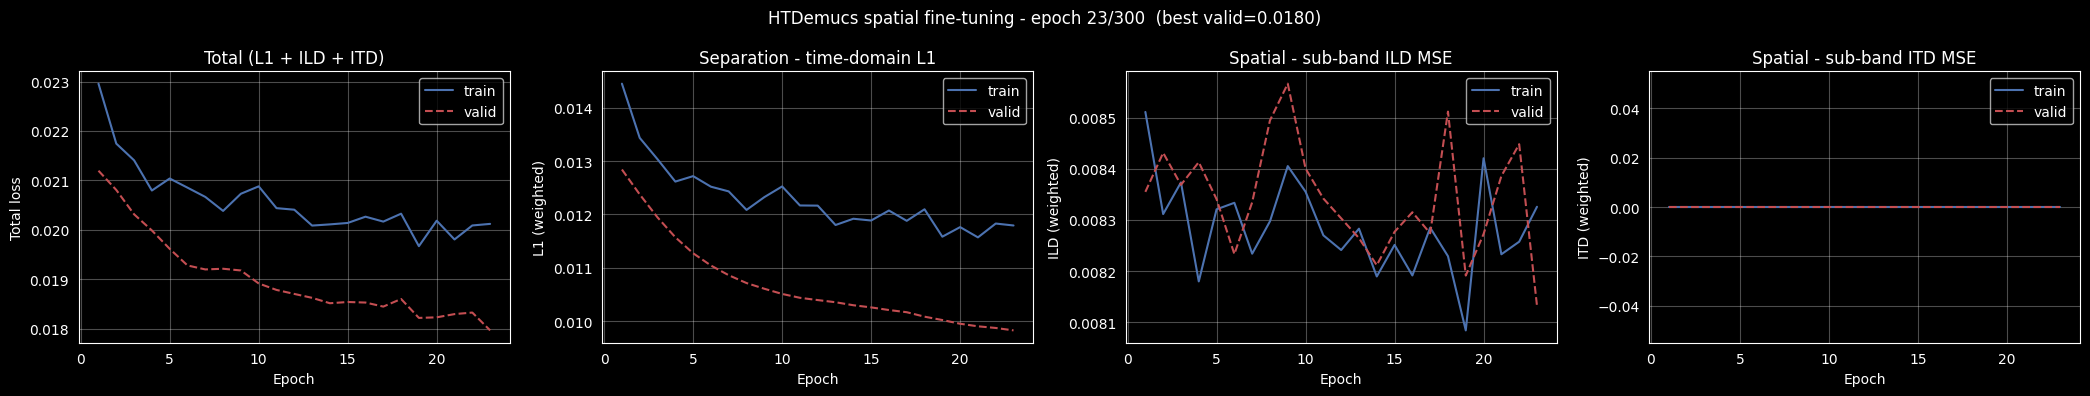

Epoch    9/300  train=0.0207 (td=0.012 ild=0.008 itd=0.000)  valid=0.0192 (td=0.011 ild=0.009 itd=0.000)  lr=9.98e-05  (860s)  <- checkpoint saved
Epoch   10/300  train=0.0209 (td=0.013 ild=0.008 itd=0.000)  valid=0.0189 (td=0.011 ild=0.008 itd=0.000)  lr=9.97e-05  (892s)  <- checkpoint saved
Epoch   11/300  train=0.0204 (td=0.012 ild=0.008 itd=0.000)  valid=0.0188 (td=0.010 ild=0.008 itd=0.000)  lr=9.97e-05  (891s)  <- checkpoint saved
Epoch   12/300  train=0.0204 (td=0.012 ild=0.008 itd=0.000)  valid=0.0187 (td=0.010 ild=0.008 itd=0.000)  lr=9.96e-05  (903s)  <- checkpoint saved
Epoch   13/300  train=0.0201 (td=0.012 ild=0.008 itd=0.000)  valid=0.0186 (td=0.010 ild=0.008 itd=0.000)  lr=9.96e-05  (890s)  <- checkpoint saved
Epoch   14/300  train=0.0201 (td=0.012 ild=0.008 itd=0.000)  valid=0.0185 (td=0.010 ild=0.008 itd=0.000)  lr=9.95e-05  (872s)  <- checkpoint saved
Epoch   15/300  train=0.0201 (td=0.012 ild=0.008 itd=0.000)  valid=0.0185 (td=0.010 ild=0.008 itd=0.000)  lr=9.94e-05 

In [ ]:
history = {
    "train_total": [], "train_td": [], "train_ild": [], "train_itd": [],
    "valid_total": [], "valid_td": [], "valid_ild": [], "valid_itd": [],
    "lr": [],
}
best_valid = math.inf
log_lines  = []   # rolling text log (survives the clear_output redraw)

@torch.no_grad()
def run_valid(model, loader):
    model.eval()
    # Deterministic validation: freeze the RNG so the random crops are
    # identical every epoch (comparable curves), then restore it so the
    # training randomness downstream is unaffected.
    _py_rng = random.getstate()
    _th_rng = torch.get_rng_state()
    random.seed(1234)
    torch.manual_seed(1234)
    tot, td, il, it, n = 0.0, 0.0, 0.0, 0.0, 0
    for mix, targets in loader:
        mix, targets = mix.to(DEVICE), targets.to(DEVICE)
        with autocast("cuda", enabled=USE_AMP):
            estimates = model(mix)    # (B, S, 2, T)
        total, l_td, l_il, l_it = spatial_loss(estimates, targets)
        tot += total.item(); td += l_td.item(); il += l_il.item(); it += l_it.item()
        n   += 1
    random.setstate(_py_rng)
    torch.set_rng_state(_th_rng)
    d = max(n, 1)
    return tot / d, td / d, il / d, it / d

def live_plot(epoch):
    """Redraw the three loss curves in-place and reprint the recent log.

    Uses clear_output(wait=True) so the cell shows a single, continuously
    updated figure instead of stacking one plot per epoch.  `history` and the
    saved checkpoint are untouched, so interrupting the run loses nothing.
    """
    clear_output(wait=True)
    ep = range(1, len(history["train_total"]) + 1)
    fig, axes = plt.subplots(1, 4, figsize=(21, 4))
    panels = [
        ("train_total", "valid_total", "Total (L1 + ILD + ITD)",      "Total loss"),
        ("train_td",    "valid_td",    "Separation - time-domain L1", "L1 (weighted)"),
        ("train_ild",   "valid_ild",   "Spatial - sub-band ILD MSE",  "ILD (weighted)"),
        ("train_itd",   "valid_itd",   "Spatial - sub-band ITD MSE",  "ITD (weighted)"),
    ]
    for ax, (tk, vk, title, ylabel) in zip(axes, panels):
        ax.plot(ep, history[tk], label="train", color="#4c72b0", linewidth=1.5)
        ax.plot(ep, history[vk], label="valid", color="#c44e52", linewidth=1.5, linestyle="--")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(); ax.grid(True, alpha=0.3)
    fig.suptitle(f"HTDemucs spatial fine-tuning - epoch {epoch}/{N_EPOCHS}  "
                 f"(best valid={best_valid:.4f})")
    plt.tight_layout(); plt.show()
    plt.close(fig)   # free the figure so 100 epochs don't leak memory
    # Reprint the tail of the textual log (cleared by clear_output above)
    print("\n".join(log_lines[-15:]))

# ── Training loop (Ctrl-C / Kernel > Interrupt stops it cleanly) ──────────────
try:
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        t0 = time.time()
        tot_loss = tot_td = tot_il = tot_it = 0.0
        n_batches = 0

        optimizer.zero_grad()

        for step, (mix, targets) in enumerate(train_loader):
            mix, targets = mix.to(DEVICE), targets.to(DEVICE)

            with autocast("cuda", enabled=USE_AMP):
                estimates = model(mix)                   # (B, S, 2, T)
            # Loss in FP32 (inputs cast inside the loss)
            total, l_td, l_il, l_it = spatial_loss(estimates, targets)
            loss_scaled = total / ACCUM_STEPS

            scaler.scale(loss_scaled).backward()

            tot_loss += total.item(); tot_td += l_td.item()
            tot_il   += l_il.item(); tot_it += l_it.item()
            n_batches += 1

            if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    max_norm=5.0,
                )
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        scheduler.step()

        d = max(n_batches, 1)
        train_total, train_td, train_il, train_it = tot_loss/d, tot_td/d, tot_il/d, tot_it/d
        if valid_loader.dataset:
            valid_total, valid_td, valid_il, valid_it = run_valid(model, valid_loader)
        else:
            valid_total = valid_td = valid_il = valid_it = float("nan")

        history["train_total"].append(train_total); history["train_td"].append(train_td)
        history["train_ild"].append(train_il);      history["train_itd"].append(train_it)
        history["valid_total"].append(valid_total); history["valid_td"].append(valid_td)
        history["valid_ild"].append(valid_il);      history["valid_itd"].append(valid_it)
        history["lr"].append(scheduler.get_last_lr()[0])

        elapsed = time.time() - t0
        log_lines.append(
            f"Epoch {epoch:4d}/{N_EPOCHS}  "
            f"train={train_total:.4f} (td={train_td:.3f} ild={train_il:.3f} itd={train_it:.3f})  "
            f"valid={valid_total:.4f} (td={valid_td:.3f} ild={valid_il:.3f} itd={valid_it:.3f})  "
            f"lr={scheduler.get_last_lr()[0]:.2e}  ({elapsed:.0f}s)"
        )

        # Save best checkpoint (by total validation loss)
        if valid_total < best_valid:
            best_valid = valid_total
            torch.save(
                {
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "optim_state": optimizer.state_dict(),
                    "history":     history,
                    "train_loss":  train_total,
                    "valid_loss":  valid_total,
                    "valid_ild":   valid_il,
                    "valid_itd":   valid_it,
                },
                CKPT_PATH,
            )
            log_lines[-1] += "  <- checkpoint saved"

        # Live in-place redraw of the curves + recent log
        live_plot(epoch)

    print("\nTraining complete.")

except KeyboardInterrupt:
    print(f"\nTraining interrupted by user at epoch {epoch}. "
          f"history and the best checkpoint are preserved.")

print(f"Best validation loss : {best_valid:.4f}")
print(f"Checkpoint           : {CKPT_PATH}")


## Load Checkpoint (run this cell to skip training)

If the fine-tuning was already completed in a previous session, load the saved
weights into `model` instead of re-training.

In [13]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint from {CKPT_PATH}\n"
      f"Epoch {ckpt['epoch']}  "
      f"valid_loss={ckpt['valid_loss']:.4f}  valid_ild={ckpt.get('valid_ild', float('nan')):.4f} "
      f"valid_itd={ckpt.get('valid_itd', float('nan')):.5f}")

Loaded checkpoint from /nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune/htdmcs_sp_decoder_tail_20260716_135536.pt
Epoch 97  valid_loss=0.0428  valid_ild=0.0339 valid_itd=0.00000


## Evaluation on the Test split - Fine-tuned HTDemucs vs HTDemucs baseline

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking), then two metrics are computed per source against the
ground-truth stems:

**SI-SDR** (separation quality)

$$\text{SI-SDR}(\hat{s}, s_{gt}) = 10\log_{10}\!\left(\frac{\big\|\tfrac{\langle \hat{s}, s_{gt}\rangle}{\|s_{gt}\|^2}\,s_{gt}\big\|^2}{\big\|\hat{s} - \tfrac{\langle \hat{s}, s_{gt}\rangle}{\|s_{gt}\|^2}\,s_{gt}\big\|^2}\right)\ \text{[dB]}$$

**Per-band ILD MAE** and **per-band ITD MAE** (spatial-cue preservation) — the
residual level / time-difference error per frequency band, averaged over time:

$$\mathrm{MAE}^{\text{ILD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ILD}}_k(t) - \mathrm{ILD}_{k,gt}(t)\big|\,[\text{dB}],\qquad
\mathrm{MAE}^{\text{ITD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ITD}}_k(t) - \mathrm{ITD}_{k,gt}(t)\big|\,[\text{samples}]$$

Both the **fine-tuned HTDemucs** (this run) and the **frozen HTDemucs baseline**
(original pre-trained weights) are run on the same tracks, so the two approaches
are compared on the identical cue definitions used during training.

In [14]:
# Sub-band cue parameters — same as the training loss / SA-HTDemucs config.
_EVAL_N_FFT   = ILD_N_FFT
_EVAL_HOP     = ILD_HOP
_EVAL_BANDS   = ILD_N_BANDS
_EVAL_SCALE   = ILD_BAND_SCALE
_EVAL_SR      = SAMPLE_RATE
_EVAL_MAX_LAG = ITD_MAX_LAG
_EVAL_BETA    = ITD_BETA

# Stem loading (`load_audio`) and the SI-SDR / per-band ILD & ITD MAE metrics
# (`si_sdr`, `ild_bands_mae`, `itd_bands_mae`) are imported from the `sahtdemucs`
# package, so the evaluation reuses the exact cue definitions of the training
# loss instead of re-implementing them here.

def separate(net: torch.nn.Module, wav: torch.Tensor) -> torch.Tensor:
    """Run an HTDemucs model on a full (2, T) mix. Returns (S, 2, T)."""
    net.eval()
    return apply_model(net, wav.unsqueeze(0), progress=False).squeeze(0)

def evaluate_on_tracks(
        net: torch.nn.Module,
        tracks,
        tag: str,
        out_dir: Optional[Path] = None,
) -> dict:
    """Separate every test track with `net` and collect per-source metrics."""
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP — no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_audio(mix_path, SAMPLE_RATE).to(DEVICE)
        stems = separate(net, wav).cpu()   # (S, 2, T)

        # Save estimated sources
        if out_dir is not None:
            track_out_dir = out_dir / track_dir.name
            track_out_dir.mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(SOURCES):
                torchaudio.save(
                    str(track_out_dir / f"{src}.wav"),
                    stems[i].cpu(),
                    SAMPLE_RATE,
                )

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_audio(tgt_path, SAMPLE_RATE)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]
            track_res[src] = dict(
                ild_bands_mae=ild_bands_mae(
                    est, tgt, n_fft=_EVAL_N_FFT, hop_length=_EVAL_HOP,
                    n_bands=_EVAL_BANDS, scale=_EVAL_SCALE, sample_rate=_EVAL_SR,
                ),
                itd_bands_mae=itd_bands_mae(
                    est, tgt, n_fft=_EVAL_N_FFT, hop_length=_EVAL_HOP,
                    n_bands=_EVAL_BANDS, scale=_EVAL_SCALE, sample_rate=_EVAL_SR,
                    max_lag=_EVAL_MAX_LAG, beta=_EVAL_BETA,
                ),
                si_sdr=si_sdr(est, tgt),
            )
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")

    print(f"{tag}: evaluation complete — {len(res)} tracks.\n")

    if out_dir is not None:
        print(f"Estimates saved to: {out_dir}")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


In [15]:
# Fine-tuned HTDemucs (this run) — `model` already holds the loaded checkpoint.
results = evaluate_on_tracks(model, tracks, tag="Fine-tuned HTDemucs", out_dir=Path(ESTIMATES_DIR))

Running Fine-tuned HTDemucs on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (18.6s)
[2/50] AM Contra - Heart Peripheral ... done (19.1s)
[3/50] Angels In Amplifiers - I'm Alright ... done (16.6s)
[4/50] Arise - Run Run Run ... done (20.1s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (23.3s)
[6/50] BKS - Bulldozer ... done (30.6s)
[7/50] BKS - Too Much ... done (20.3s)
[8/50] Bobby Nobody - Stitch Up ... done (20.2s)
[9/50] Buitraker - Revo X ... done (25.3s)
[10/50] Carlos Gonzalez - A Place For Us ... done (23.1s)
[11/50] Cristina Vane - So Easy ... done (23.3s)
[12/50] Detsky Sad - Walkie Talkie ... done (17.6s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (16.9s)
[14/50] Forkupines - Semantics ... done (25.1s)
[15/50] Georgia Wonder - Siren ... done (41.1s)
[16/50] Girls Under Glass - We Feel Alright ... done (29.7s)
[17/50] Hollow Ground - Ill Fate ... done (13.8s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (19.4

## HTDemucs Baseline Evaluation

Run the **frozen, original pre-trained HTDemucs** (fresh weights, no fine-tuning)
on the same test tracks to build `results_baseline` with the same structure as
`results`.

In [9]:
# Fresh pre-trained HTDemucs as the spatial baseline
baseline_bag = get_model("htdemucs")
baseline = baseline_bag.models[0] if hasattr(baseline_bag, "models") else baseline_bag
baseline = baseline.to(DEVICE).eval()

results_baseline = evaluate_on_tracks(baseline, tracks, tag="HTDemucs baseline")

Running HTDemucs baseline on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (12.5s)
[2/50] AM Contra - Heart Peripheral ... done (13.4s)
[3/50] Angels In Amplifiers - I'm Alright ... done (11.2s)
[4/50] Arise - Run Run Run ... done (13.9s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (15.8s)
[6/50] BKS - Bulldozer ... done (21.3s)
[7/50] BKS - Too Much ... done (14.3s)
[8/50] Bobby Nobody - Stitch Up ... done (13.9s)
[9/50] Buitraker - Revo X ... done (17.5s)
[10/50] Carlos Gonzalez - A Place For Us ... done (15.5s)
[11/50] Cristina Vane - So Easy ... done (16.2s)
[12/50] Detsky Sad - Walkie Talkie ... done (12.0s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (11.9s)
[14/50] Forkupines - Semantics ... done (17.0s)
[15/50] Georgia Wonder - Siren ... done (28.4s)
[16/50] Girls Under Glass - We Feel Alright ... done (19.7s)
[17/50] Hollow Ground - Ill Fate ... done (9.1s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (13.1s)


## SI-SDR per Source - Fine-tuned vs Baseline

Checks that separation quality is preserved after the spatial fine-tuning:
SI-SDR should stay close to the HTDemucs baseline while the ILD MAE (next
section) drops.

In [16]:
def _aggregate(res):
    ag = {src: {"ild_bands_mae": [], "itd_bands_mae": [], "si_sdr": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
            ag[src]["itd_bands_mae"].append(m["itd_bands_mae"])
            ag[src]["si_sdr"].append(m["si_sdr"])
    return ag

def _stats(ag):
    return {
        "mean_si_sdr": {s: np.mean(ag[s]["si_sdr"]) for s in SOURCES},
        "mean_ild_mae_bands": {s: np.mean(ag[s]["ild_bands_mae"], axis=0) for s in SOURCES},
        "mean_itd_mae_bands": {s: np.mean(ag[s]["itd_bands_mae"], axis=0) for s in SOURCES},
    }

agg          = _aggregate(results)
agg_baseline = _aggregate(results_baseline)
stats        = _stats(agg)
stats_bl     = _stats(agg_baseline)

def _mean_all(st, key):
    return float(np.mean([st[key][s] for s in SOURCES]))

# ITD is stored in samples (the loss unit); display it in microseconds.
_US = 1e6 / SAMPLE_RATE   # µs per sample (≈ 22.68 µs @ 44.1 kHz)

print("Fine-tuned HTDemucs vs HTDemucs baseline")
print(f"{'Source':<9}| {'SI-SDR ft [dB]':>10} {'SI-SDR bl [dB]':>10} {'dSI [dB]':>10}")
print("-" * 50)
for src in SOURCES:
    si_ft, si_bl = stats["mean_si_sdr"][src], stats_bl["mean_si_sdr"][src]
    print(f"{src:<9}| {si_ft:>+7.2f} {si_bl:>+7.2f} {si_ft - si_bl:>+7.2f}")
print("-" * 50)
si_ft, si_bl = _mean_all(stats, "mean_si_sdr"),  _mean_all(stats_bl, "mean_si_sdr")
print(f"{'All':<9}| {si_ft:>+7.2f} {si_bl:>+7.2f} {si_ft - si_bl:>+6.2f}")
print("\ndSI > 0 -> separation preserved/improved.")

Fine-tuned HTDemucs vs HTDemucs baseline
Source   | SI-SDR ft [dB] SI-SDR bl [dB]   dSI [dB]
--------------------------------------------------
drums    |   +8.85   +9.78   -0.93
bass     |   +7.66   +7.98   -0.32
other    |   +3.92   +4.29   -0.37
vocals   |   +7.44   +7.86   -0.42
--------------------------------------------------
All      |   +6.97   +7.48  -0.51

dSI > 0 -> separation preserved/improved.


## Mean per-band ILD & ITD MAE over the test set

For band $k$ and source $s$, the plotted value is the mean absolute cue error
across all $N$ test tracks.

- **Top row: ILD MAE** (dB).
- **Bottom row: ITD MAE** (µs — the loss uses samples internally, converted here for readability via
$1\,\text{sample} = 10^6/f_s\ \mu s \approx 22.7\,\mu s$ @ 44.1 kHz).

- **Left column**: the **fine-tuned HTDemucs**.
- **Right column**: the **frozen baseline**.

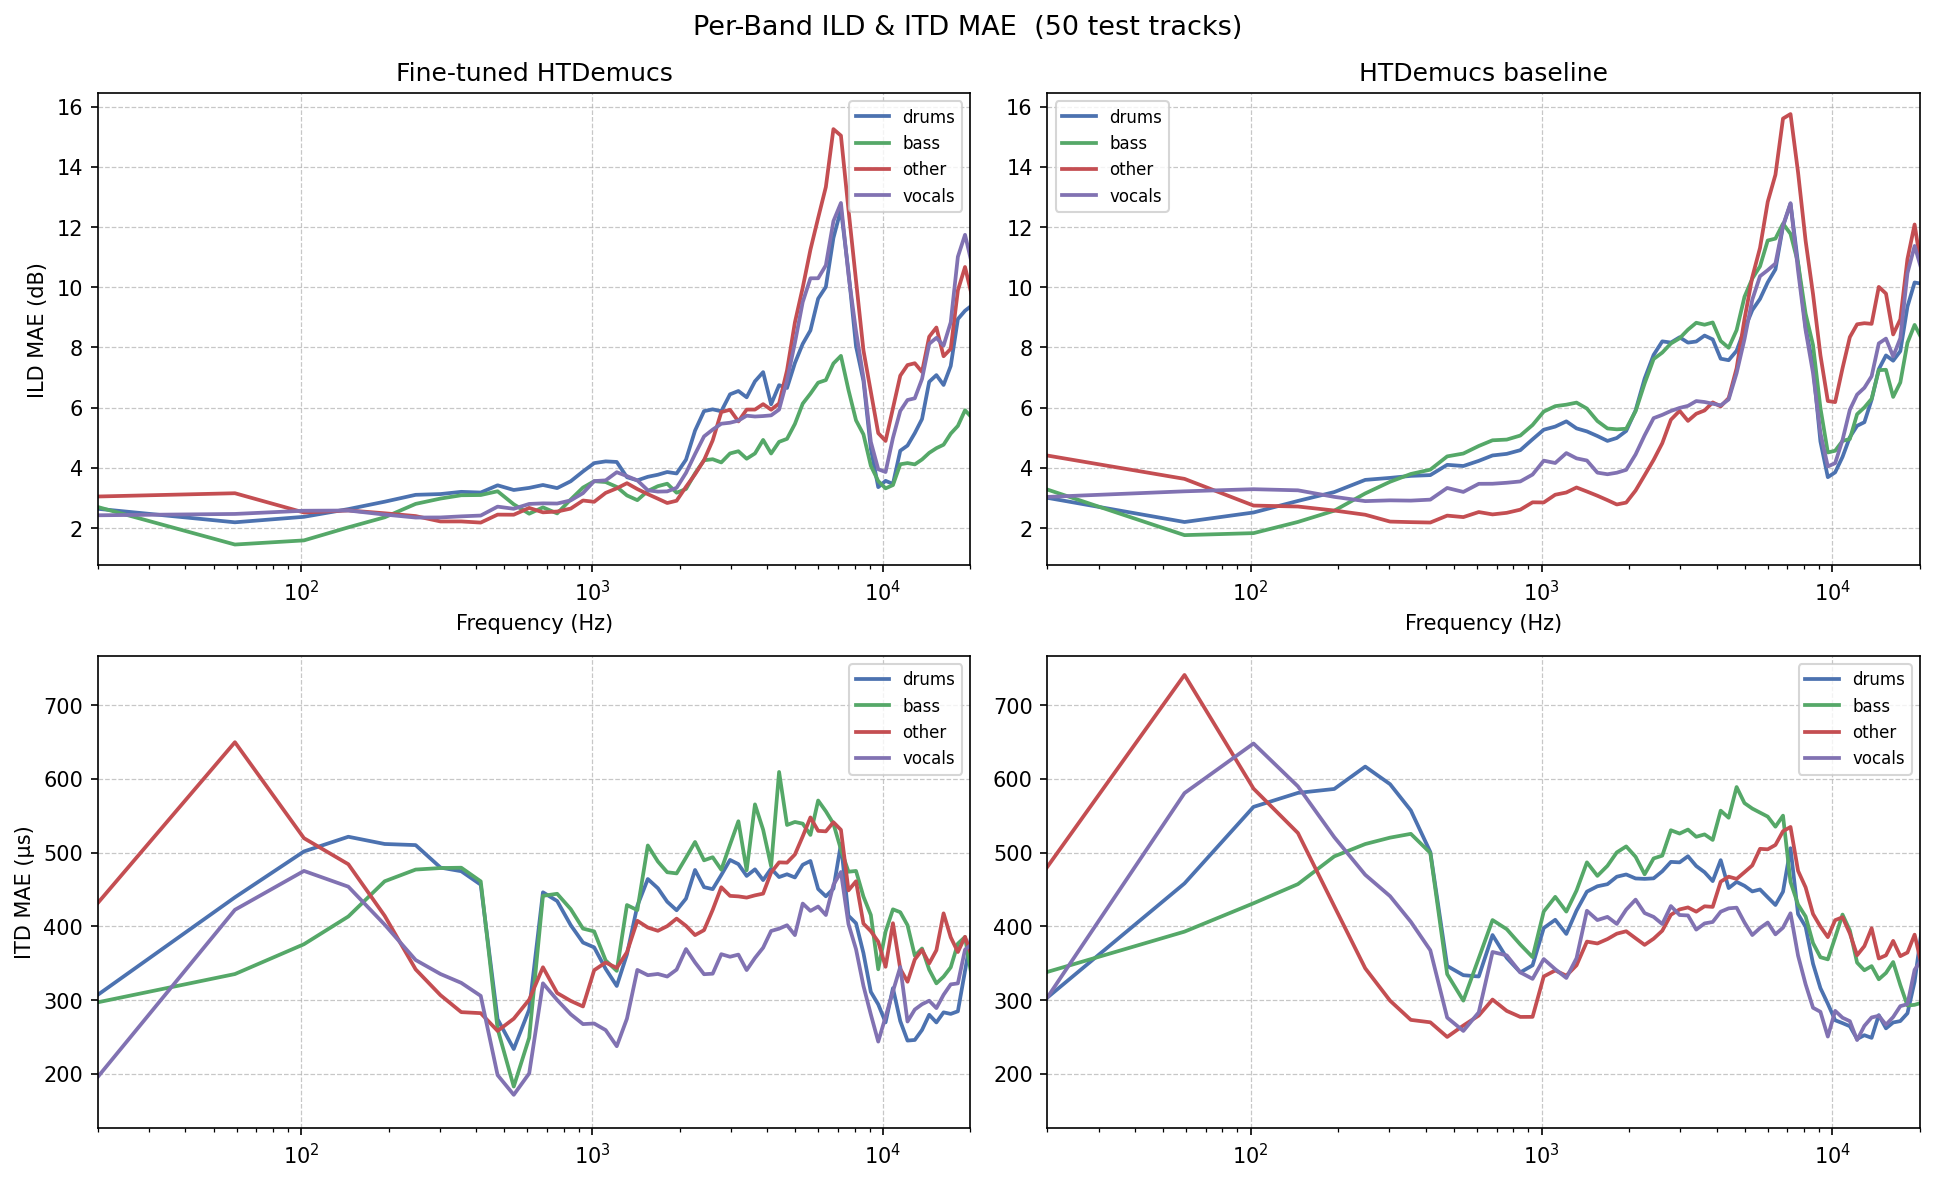

In [17]:
n_bands = len(next(iter(stats["mean_ild_mae_bands"].values())))

# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
if _EVAL_SCALE == "mel":
    _ba     = mel_bin_assignment(int(_EVAL_N_FFT), n_bands, int(_EVAL_SR))
    _bin_hz = np.arange(int(_EVAL_N_FFT) // 2 + 1) * (int(_EVAL_SR) / int(_EVAL_N_FFT))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

# ITD is stored in samples (the loss unit); display it in microseconds.
_US = 1e6 / SAMPLE_RATE   # µs per sample (≈ 22.68 µs @ 44.1 kHz)

# Rows: (metric key, y-label, display scale);  Columns: (stats dict, title)
_rows = [
    ("mean_ild_mae_bands", "ILD MAE (dB)", 1.0,  (20, 20000)),
    ("mean_itd_mae_bands", "ITD MAE (µs)", _US,  (20, 20000)),
]
_cols = [(stats, "Fine-tuned HTDemucs"), (stats_bl, "HTDemucs baseline")]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150)
for r, (mkey, ylabel, scale, xlim) in enumerate(_rows):
    for c, (st, title) in enumerate(_cols):
        ax = axes[r, c]
        for i, src in enumerate(SOURCES):
            ax.plot(band_hz, st[mkey][src] * scale, label=src, color=COLORS[i], lw=1.8)
        ax.set_xscale("log")
        ax.set_ylabel(ylabel if c == 0 else "")
        if r == 0:
            ax.set_title(title)
        #if r == len(_rows) - 1:
            ax.set_xlabel("Frequency (Hz)")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
    # Share y-scale across the two columns of a row for fair comparison.
    y0 = min(axes[r, 0].get_ylim()[0], axes[r, 1].get_ylim()[0])
    y1 = max(axes[r, 0].get_ylim()[1], axes[r, 1].get_ylim()[1])
    axes[r, 0].set_ylim(y0, y1); axes[r, 1].set_ylim(y0, y1)
    axes[r, 0].set_xlim(xlim)
    axes[r, 1].set_xlim(xlim)

plt.suptitle(f"Per-Band ILD & ITD MAE  ({len(results)} test tracks)", fontsize=13)
plt.tight_layout()
plt.show()